In [2]:
import torch, os
import numpy as np

from glob import glob
from utils.data import Dataset, cycle
from utils.helper import fix_seeds, load_model
from models.particle_transformer import ParticleTransformer
from torch.utils.data import DataLoader

test_files = glob('data/test/DYJetsToMuMu_H2ErratumFix_TuneCP5_13TeV-powhegMiNNLO-pythia8-photos/*.hdf5')
dataset_test = Dataset(files=test_files, max_PF_num=2**10, print_info=True)
dataloader_test = DataLoader(
    dataset=dataset_test, batch_size=320, drop_last=False, shuffle=False,
    num_workers=8, pin_memory=True,
)
test_loader = cycle(dataloader_test)
X_test, Y_test = next(test_loader)

model = ParticleTransformer(
    input_dim=len(dataset_test.features), output_dim=len(dataset_test.truths),
    pair_input_dim=4, use_pre_activation_pair=False, embed_dims=[16, 64, 16],
    pair_embed_dims=[8, 8, 8], num_heads=4, num_layers=4, num_cls_layers=2, block_params=None,
    cls_block_params={'dropout': 0, 'attn_dropout': 0, 'activation_dropout': 0},
    fc_params=[], activation='gelu', trim=True, for_inference=False,
)
print(f'Model parameters: {sum(p.numel() for p in model.parameters()):,}')

trained_model = load_model(model, 'checkpoints/DeepMET_ParT/20260124_022543/checkpoint_best.pt')


Lazy loading data
	Lazy loaded 211,410 events from 2 files with maxPFnum = 1024
	Input features: PF_pt,PF_eta,PF_phi,PF_mass,PF_d0,PF_dz,PF_hcalFraction,PF_pdgId,PF_charge,PF_fromPV,PF_puppiWeightNoLep,PF_puppiWeight,PF_px,PF_py
	Ground truths: px, py
Model parameters: 23,710

Checkpoint loaded from checkpoints/DeepMET_ParT/20260124_022543/checkpoint_best.pt


In [3]:
y_pred = trained_model(X_test)

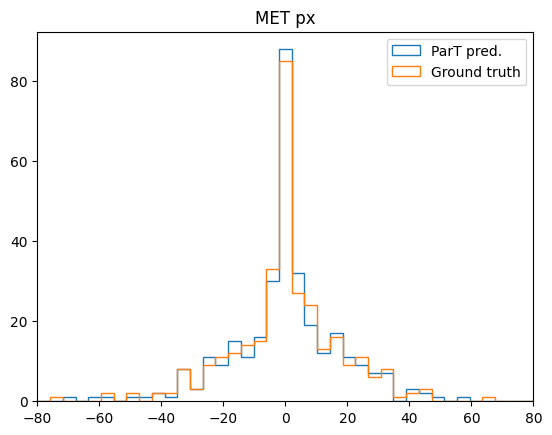

In [4]:
import matplotlib.pyplot as plt

bins = np.linspace(-80, 80, 40)

MET_pred_px = y_pred[:,0].detach().numpy()
MET_truth_px = Y_test[:,0].detach().numpy()

plt.hist(MET_truth_px, bins=bins, label='ParT pred.', histtype='step')
plt.hist(MET_pred_px, bins=bins, label='Ground truth', histtype='step')
plt.legend()
plt.xlim(bins[0], bins[-1])
plt.title(f'MET px')
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/MET_px.pdf')

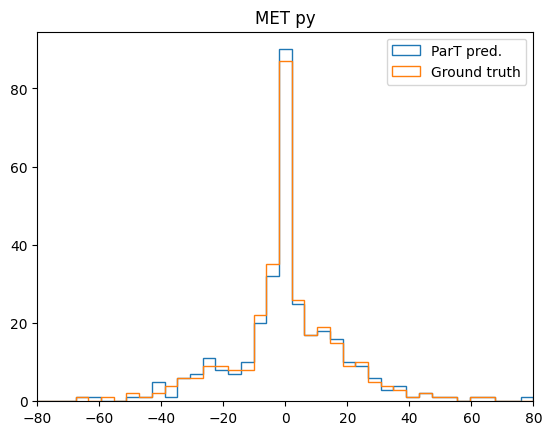

In [5]:
MET_truth_py = Y_test[:,1].detach().numpy()
MET_pred_py = y_pred[:,1].detach().numpy()

plt.hist(MET_truth_py, bins=bins, label='ParT pred.', histtype='step')
plt.hist(MET_pred_py, bins=bins, label='Ground truth', histtype='step')
plt.legend()
plt.xlim(bins[0], bins[-1])
plt.title(f'MET py')
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/MET_py.pdf')

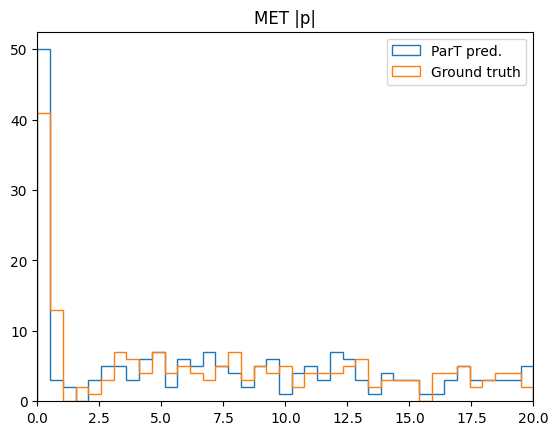

In [6]:
bins = np.linspace(0, 20, 40)
MET_truth_p = torch.sqrt(torch.sum(Y_test**2, dim=1)).detach().numpy()
MET_pred_p = torch.sqrt(torch.sum(y_pred**2, dim=1)).detach().numpy()

plt.hist(MET_truth_p, bins=bins, label='ParT pred.', histtype='step')
plt.hist(MET_pred_p, bins=bins, label='Ground truth', histtype='step')
plt.legend()
plt.xlim(bins[0], bins[-1])
plt.title(f'MET |p|')
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/MET_p.pdf')

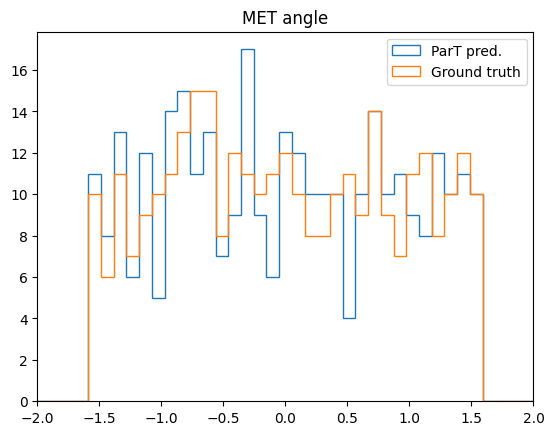

In [7]:
bins = np.linspace(-2, 2, 40)
MET_truth_angle = torch.arctan(Y_test[:, 1]/Y_test[:, 0]).detach().numpy()
MET_pred_angle = torch.arctan(y_pred[:, 1]/y_pred[:, 0]).detach().numpy()

plt.hist(MET_truth_angle, bins=bins, label='ParT pred.', histtype='step')
plt.hist(MET_pred_angle, bins=bins, label='Ground truth', histtype='step')
plt.legend()
plt.xlim(bins[0], bins[-1])
plt.title(f'MET angle')
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/MET_angle.pdf')